In [3]:
import numpy as np
import pandas as pd
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from collections import defaultdict
import warnings
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

warnings.filterwarnings('ignore')

In [4]:
gmt = {}
with open('/Users/anna/Projects/Gene-Knowledge-Graph/public/l1000_consensus_top_30_moa.gmt', 'r') as f:
    for line in f:
        tks = line.split("\t")
        gmt[tks[0]] = tks[2:]

In [5]:
gmt.keys()

dict_keys(['dopamine receptor antagonists:up', 'glucocorticoid receptor agonists:up', 'adrenergic receptor antagonists:up', 'cyclooxygenase inhibitors:up', 'histamine receptor antagonists:up', 'calcium channel blockers:up', 'tubulin polymerization inhibitors:up', 'phosphodiesterase inhibitors:up', 'bacterial cell wall synthesis inhibitors:up', 'adrenergic receptor agonists:up', 'acetylcholine receptor antagonists:up', 'PARP inhibitors:up', 'selective serotonin reuptake inhibitors (SSRIs):up', 'PI3K inhibitors:up', 'HIV protease inhibitors:up', 'adenosine receptor agonists:up', 'serotonin receptor antagonists:up', 'sodium channel blockers:up', 'mTOR inhibitors:up', 'HDAC inhibitors:up', 'HMGCR inhibitors:up', 'bacterial DNA gyrase inhibitors:up', 'AKT inhibitors:up', 'ATPase inhibitors:up', 'DNA synthesis inhibitors:up', 'estrogen receptor agonists:up', 'potassium channel blockers:up', 'Aurora kinase inhibitors:up', 'bacterial 50S ribosomal subunit inhibitors:up', 'potassium channel act

In [6]:
def get_cheakg_results(chea_gene_list, desc="", term_limit=10):
    '''
    Find the subnetwork of enriched TFs for an input gene list
    '''
    CHEA_KG = 'https://chea-kg.maayanlab.cloud/api/enrichment'
        
    payload = {
        'list': (None, "\n".join(chea_gene_list)),
        'description': (None, desc)
    }
    try:
        response=requests.post(f"{CHEA_KG}/addList", files=payload)
        data = json.loads(response.text)
    except Exception as e: 
        print("Error connecting to ChEA-KG: ", e)
    
    q = {
        'min_lib': 3, # minimum number of libraries that a TF must be ranked in
        'libraries': [
            {'library': "Integrated--meanRank", 'term_limit': term_limit} # edit term_limit to change number of top-ranked TFs
        ],
        'limit':50, # controls number of edges returned - may cause issues with visualization if too large
        'userListId': data['userListId']
    }
    
    query_json=json.dumps(q)
    
    res = requests.post(CHEA_KG, data=query_json)
    if res.ok:
        data = json.loads(res.text)
    else:
        data = None
        print(res.text)
    return data

In [7]:
networks = {}
for term, gs in gmt.items():
    networks[term] = get_cheakg_results(gs, desc=term, term_limit=10)

In [49]:
networks.keys()

dict_keys(['dopamine receptor antagonists:up', 'glucocorticoid receptor agonists:up', 'adrenergic receptor antagonists:up', 'cyclooxygenase inhibitors:up', 'histamine receptor antagonists:up', 'calcium channel blockers:up', 'tubulin polymerization inhibitors:up', 'phosphodiesterase inhibitors:up', 'bacterial cell wall synthesis inhibitors:up', 'adrenergic receptor agonists:up', 'acetylcholine receptor antagonists:up', 'PARP inhibitors:up', 'selective serotonin reuptake inhibitors (SSRIs):up', 'PI3K inhibitors:up', 'HIV protease inhibitors:up', 'adenosine receptor agonists:up', 'serotonin receptor antagonists:up', 'sodium channel blockers:up', 'mTOR inhibitors:up', 'HDAC inhibitors:up', 'HMGCR inhibitors:up', 'bacterial DNA gyrase inhibitors:up', 'AKT inhibitors:up', 'ATPase inhibitors:up', 'DNA synthesis inhibitors:up', 'estrogen receptor agonists:up', 'potassium channel blockers:up', 'Aurora kinase inhibitors:up', 'bacterial 50S ribosomal subunit inhibitors:up', 'potassium channel act

In [12]:
with open("./moa-atlas-subnetworks.json", 'w') as f:
    json.dump(networks, f)

In [40]:
networks

{'dopamine receptor antagonists:up': {'nodes': [{'data': {'id': 3664,
     'kind': 'Top Ranked TFs',
     'label': 'IRF6',
     'HGNC': 'HGNC:6121',
     'Ensembl': 'ENSG00000117595',
     'uri': 'https://www.ncbi.nlm.nih.gov/gene/3664',
     'library': 'Integrated--meanRank',
     'enrichr_label': 'IRF6',
     'score': 34.33,
     'rank': '2',
     'overlap': 36,
     'libs': [{'library': 'ARCHS4 Coexpression', 'score': 55},
      {'library': 'Enrichr Queries', 'score': 20},
      {'library': 'GTEx Coexpression', 'score': 28}],
     'rank_sum': 103,
     'value': 0.46568093385214016,
     'node_type': 0,
     'borderWidth': 0,
     'gradient_color': '#8ad6ff',
     'color': '#8ad6ff'}},
   {'data': {'id': 26298,
     'kind': 'Top Ranked TFs',
     'label': 'EHF',
     'HGNC': 'HGNC:3246',
     'Ensembl': 'ENSG00000135373',
     'uri': 'https://www.ncbi.nlm.nih.gov/gene/26298',
     'library': 'Integrated--meanRank',
     'enrichr_label': 'EHF',
     'score': 45.25,
     'rank': '5',
 

# Create big adjacency matrix
NxN where N = total unique TFs covered by all terms
color each edge by direction
color each edge by term ? not sure if there are enough colors for this

following code generated using claude sonnet4.5: https://claude.ai/chat/3fb06dd5-cd9f-47cc-80c9-b044a2da9c7e

In [187]:
def create_adjacency_matrices(subnetworks_dict, track_frequency=False):
    """
    Create adjacency matrix visualizations for subnetwork collection.

    subnetworks_dict : Dictionary where keys are subnetwork titles and values are JSON objects
    containing 'nodes' and 'edges' lists
    """
    
    # Step 1: Collect all unique nodes and edges
    edge_counts = defaultdict(lambda: {'up': 0, 'down': 0})
    
    for subnetwork_data in subnetworks_dict.values():
       
        # Extract edges
        edges = subnetwork_data.get('edges', [])
        for edge in edges:
            edge_data = edge['data']
            source = edge_data['source']
            target = edge_data['target']
            relation = edge_data.get('relation', edge_data.get('label', ''))
            
            # Determine if edge is up or down regulation
            if 'up' in relation.lower():
                if track_frequency:
                    edge_counts[(source, target)]['up'] += 1
                else:
                    edge_counts[(source, target)]['up'] = 1
            elif 'down' in relation.lower():
                if track_frequency:
                    edge_counts[(source, target)]['down'] += 1
                else:
                    edge_counts[(source, target)]['down'] = 1
    
    # only keep nodes that are involved in edges
    edge_nodes = set(x for pair in edge_counts.keys() for x in pair)

    # Step 2: Create sorted node list
    all_nodes = sorted(list(edge_nodes))
    n_nodes = len(all_nodes)
    node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
    
    # Step 3: Create adjacency matrices
    up_matrix = np.zeros((n_nodes, n_nodes))
    down_matrix = np.zeros((n_nodes, n_nodes))
    
    for (source, target), counts in edge_counts.items():
        if source in node_to_idx and target in node_to_idx:
            i = node_to_idx[source]
            j = node_to_idx[target]
            up_matrix[i, j] = counts['up']
            down_matrix[i, j] = counts['down']
    
    # Step 4: Create combined matrix for visualization (downregulated edges are negative)
    combined_matrix = up_matrix - down_matrix
    
    return all_nodes, up_matrix, down_matrix, combined_matrix


def get_node_labels(subnetworks_dict, node_ids):
    """
    Extract node labels from the subnetwork data.
    subnetworks_dict : Dictionary of subnetworks
    node_ids : List of node IDs
    
    Returns list of node labels corresponding to node IDs
    """
    id_to_label = {}
    
    for subnetwork_data in subnetworks_dict.values():
        nodes = subnetwork_data.get('nodes', [])
        for node in nodes:
            node_id = node['data']['id']
            node_label = node['data'].get('label', str(node_id))
            id_to_label[node_id] = node_label
    
    return [id_to_label.get(node_id, str(node_id)) for node_id in node_ids]


def plot_adjacency_matrix(combined_matrix, node_labels, title="Subnetwork Adjacency Matrix",
                          figsize=(16, 14), save_path=None, cmap='binary', maskzero=False):
    """
    Plot the combined adjacency matrix with red for upregulation and green for downregulation.

    combined_matrix : Combined matrix (positive = up, negative = down)
    node_labels : Labels for nodes
    title : Plot title
    figsize : Figure size
    save_path : Path to save the figure
    """
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot heatmap
    max_val = np.max(np.abs(combined_matrix))
    masked_matrix=combined_matrix
    
    if maskzero:
        masked_matrix = np.ma.masked_where(combined_matrix == 0, combined_matrix)
        cmap.set_bad(color='white')
    
    im = ax.imshow(masked_matrix, cmap=cmap, aspect='auto',
                   vmin=-max_val, vmax=max_val, interpolation='nearest')
    

    # Add colorbar
    if cmap != 'binary':
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Edge Frequency)', 
                    rotation=270, labelpad=25, fontsize=11)
    
    # Set ticks and labels
    n_nodes = len(node_labels)
    
    # Show all labels if reasonable, otherwise sample
    if n_nodes <= 50:
        tick_positions = np.arange(n_nodes)
        tick_labels = node_labels
        fontsize = max(6, min(10, 400 // n_nodes))
    else:
        # Sample every nth label
        step = max(1, n_nodes // 40)
        tick_positions = np.arange(0, n_nodes, step)
        tick_labels = [node_labels[i] for i in tick_positions]
        fontsize = 8
    
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=90, ha='right', fontsize=fontsize)
    ax.set_yticklabels(tick_labels, fontsize=fontsize)
    
    # Labels and title
    ax.set_xlabel('Target TFs', fontsize=12, fontweight='bold')
    ax.set_ylabel('Source TFs', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Add grid
    ax.grid(False)
    
    # Add subtle gridlines
    ax.set_xticks(np.arange(n_nodes) - 0.5, minor=True)
    ax.set_yticks(np.arange(n_nodes) - 0.5, minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.1, alpha=0.2)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved figure to {save_path}")
    
    return fig, ax


def plot_clustermap(combined_matrix, node_labels, 
                    figsize=(18, 16), save_path=None, cmap='viridis',
                    binary=False, maskzero=False, cbar_pos=None):

    # Create DataFrame for plotting (signed values for coloring)
    df = pd.DataFrame(combined_matrix, index=node_labels, columns=node_labels)

    if maskzero:
        cmap.set_bad(color='white')

    fontsize = 5

    # --- NEW: binary matrix for clustering only ---
    if binary:
        cluster_matrix = (combined_matrix != 0).astype(int)
    else:
        cluster_matrix = combined_matrix.copy()

    # Compute linkage on cluster_matrix (NOT the colored matrix)
    row_linkage = linkage(pdist(cluster_matrix), method='average')
    col_linkage = linkage(pdist(cluster_matrix.T), method='average')

    # Coloring range still based on signed matrix
    vmin = -np.max(np.abs(combined_matrix))
    vmax =  np.max(np.abs(combined_matrix))

    # Mask zeros visually if desired
    if not binary:
        df = df.replace(0, np.nan)

    g = sns.clustermap(df,
                       cmap=cmap,
                       vmin=vmin,
                       vmax=vmax,
                       row_linkage=row_linkage,
                       col_linkage=col_linkage,
                       figsize=figsize,
                       cbar_kws={'label': 'Edge Direction (+/-)'},
                       dendrogram_ratio=0.1,
                       linewidths=0,
                       xticklabels=False,
                       yticklabels=False,
                       cbar_pos=(1,0.4,0.05,0.2)
                       )

    g.ax_heatmap.set_xlabel('Target TFs', fontsize=11, fontweight='bold')
    g.ax_heatmap.set_ylabel('Source TFs', fontsize=11, fontweight='bold')
    g.cax.set_yticks([-1, 0, 1])
    g.cax.set_yticklabels(['Down', 'No edge', 'Up'])

    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(),
             rotation=90, ha='center', fontsize=fontsize)
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(),
             rotation=0, fontsize=fontsize)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.savefig(save_path.replace(".png", ".svg"),
                    dpi=300, bbox_inches='tight')

    return g

In [188]:
import matplotlib.colors as mcolors
import random

Found 97 unique nodes


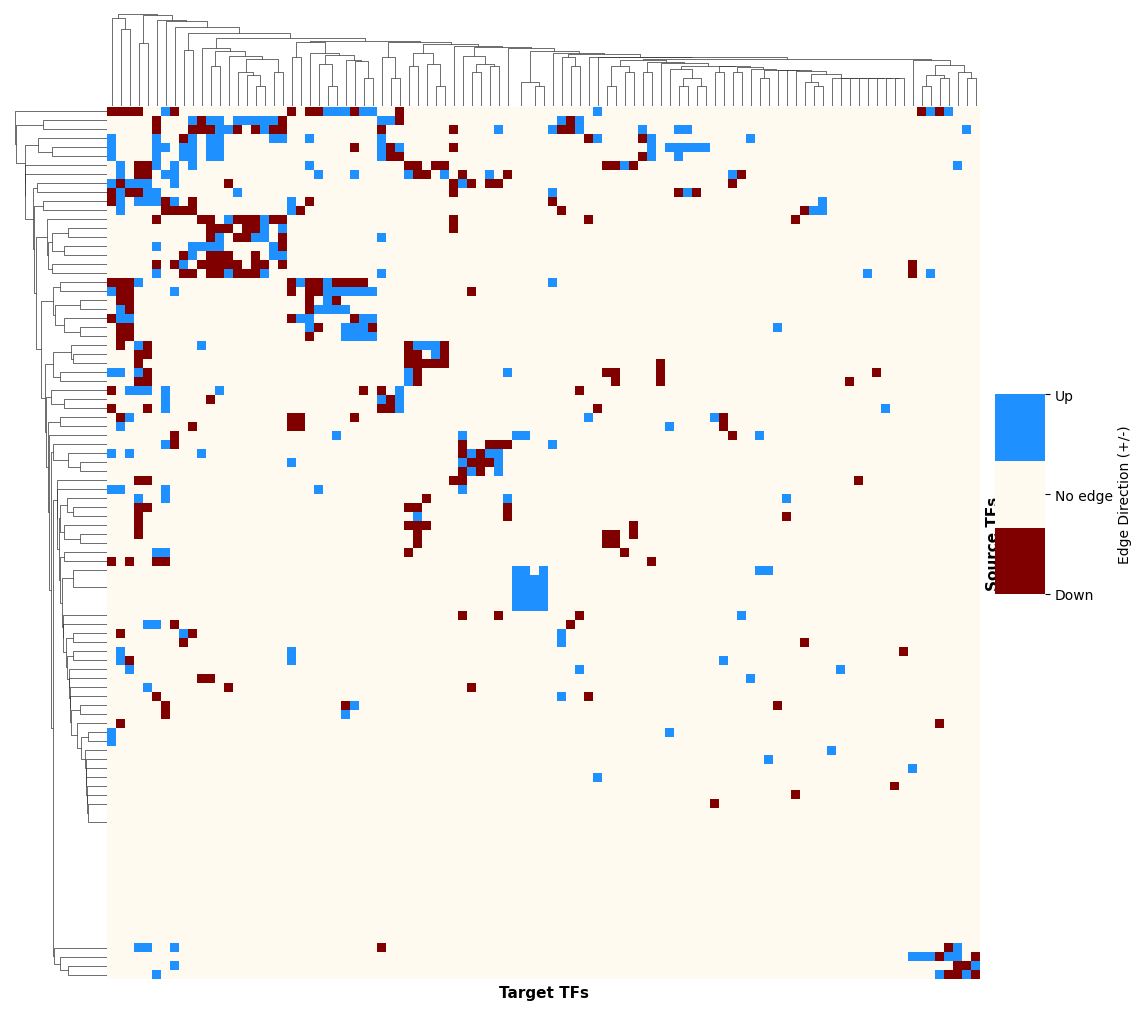

In [190]:
output_prefix = "non_directional_no_text"
# Create adjacency matrices
all_nodes, up_matrix, down_matrix, combined_matrix = create_adjacency_matrices(networks)
print(f"Found {len(all_nodes)} unique nodes")
 
# combined_matrix = np.where(combined_matrix != 0,1,0)
# Get node labels
node_labels = get_node_labels(networks, all_nodes)

# Create visualizations
results = {}
colors = ['maroon', "floralwhite", "dodgerblue"] # Example colors
binary_cmap = LinearSegmentedColormap.from_list("CustomBinary", colors, len(colors))

g = plot_clustermap(
    combined_matrix,
    node_labels,
    save_path=f"./moa_atlas_figs/{output_prefix}_clustermap.png",
    figsize=(10,10),
    cmap=binary_cmap,
    binary=True,
    maskzero=False
)

plt.show()

In [ ]:
combined_matrix[1,1]

np.int64(1)

Found 97 unique nodes
30.0
Saved clustermap to ./moa_atlas_figs/non_directional_clustermap.png


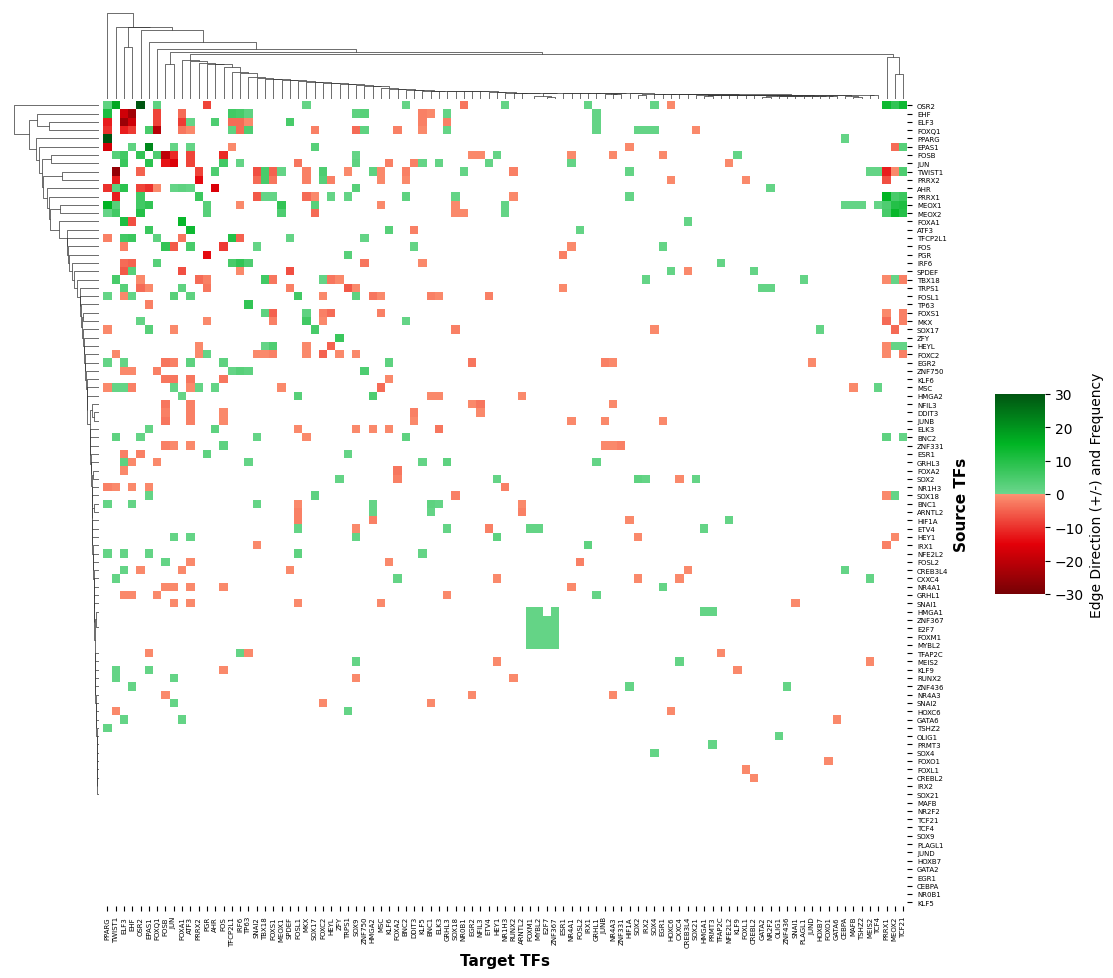

In [253]:
all_nodes, up_matrix, down_matrix, combined_matrix = create_adjacency_matrices(networks, track_frequency=True)
print(f"Found {len(all_nodes)} unique nodes")
 
# Create custom diverging colormap
colors_green = [ "#6bd68d", "#00B524", "#005511",]
colors_red = ['#fc9272', "#E30008", "#760105"]

n_bins = 256
cmap_green = LinearSegmentedColormap.from_list('greens', colors_green, N=n_bins//2)
cmap_red = LinearSegmentedColormap.from_list('reds', colors_red[::-1], N=n_bins//2)

colors = np.vstack((cmap_red(np.linspace(0, 1, n_bins//2)),
                    cmap_green(np.linspace(0, 1, n_bins//2))))
diverging_cmap = LinearSegmentedColormap.from_list('green_red', colors)

g = plot_clustermap(
    combined_matrix,
    node_labels,
    save_path=f"./moa_atlas_figs/{output_prefix}_clustermap.png",
    figsize=(10,10),
    cmap=diverging_cmap,
    maskzero=True,
    binary=False
)

plt.show()

In [182]:
def create_adjacency_matrices_moa(subnetworks_dict, moa_to_values):
    edge_values = {}

    for term, subnetwork_data in subnetworks_dict.items():
        moa_id = moa_to_values[term.split(':')[0]]

        edges = subnetwork_data.get('edges', [])
        for edge in edges:
            edge_data = edge['data']
            source = edge_data['source']
            target = edge_data['target']

            # Assign MOA category directly
            if (source,target) in ['']:
                moa_id = moa_to_values['multiple']
            else:
                edge_values[(source, target)] = moa_id
            

    edge_nodes = set(x for pair in edge_values.keys() for x in pair)

    all_nodes = sorted(list(edge_nodes))
    n_nodes = len(all_nodes)
    node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}

    adj_matrix = np.zeros((n_nodes, n_nodes))

    for (source, target), moa_id in edge_values.items():
        i = node_to_idx[source]
        j = node_to_idx[target]
        adj_matrix[i, j] = moa_id

    return all_nodes, adj_matrix

In [183]:
def plot_moa_clustermap(combined_matrix, node_labels, colors=None,
                    figsize=(18, 16), save_path=None, cmap='viridis',
                    binary=False, maskzero=False, cbar_pos=None):

    # Create DataFrame for plotting (signed values for coloring)
    df = pd.DataFrame(combined_matrix, index=node_labels, columns=node_labels)

    

    fontsize = 5

    if binary:
        cluster_matrix = (combined_matrix != 0).astype(int)
    else:
        cluster_matrix = combined_matrix.copy()
    
    if maskzero:
        cmap.set_bad(color='floralwhite')

    # Compute linkage on cluster_matrix (NOT the colored matrix)
    row_linkage = linkage(pdist(cluster_matrix), method='average')
    col_linkage = linkage(pdist(cluster_matrix.T), method='average')

    # Coloring range still based on signed matrix
    vmin = 0
    vmax = len(colors)

    # Mask zeros visually if desired
    if binary:
        df = df.replace(0, np.nan)

    g = sns.clustermap(df,
                       cmap=cmap,
                       vmin=vmin,
                       vmax=vmax,
                       row_linkage=row_linkage,
                       col_linkage=col_linkage,
                       figsize=figsize,
                       cbar_kws={'label': 'MoA'},
                       dendrogram_ratio=0.1,
                       linewidths=0,
                       xticklabels=False,
                       yticklabels=False,
                       cbar_pos=(1.06,0.4,0.05,0.5)
                       )

    g.ax_heatmap.set_xlabel('Target TFs', fontsize=11, fontweight='bold')
    g.ax_heatmap.set_ylabel('Source TFs', fontsize=11, fontweight='bold')
    
    g.cax.set_yticks(list(colors.values()))
    g.cax.set_yticklabels(list(colors.keys()))

    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(),
             rotation=90, ha='center', fontsize=fontsize)
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(),
             rotation=0, fontsize=fontsize)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.savefig(save_path.replace(".png", ".svg"),
                    dpi=300, bbox_inches='tight')

    return g

In [184]:
from matplotlib.colors import ListedColormap

Found 97 unique nodes


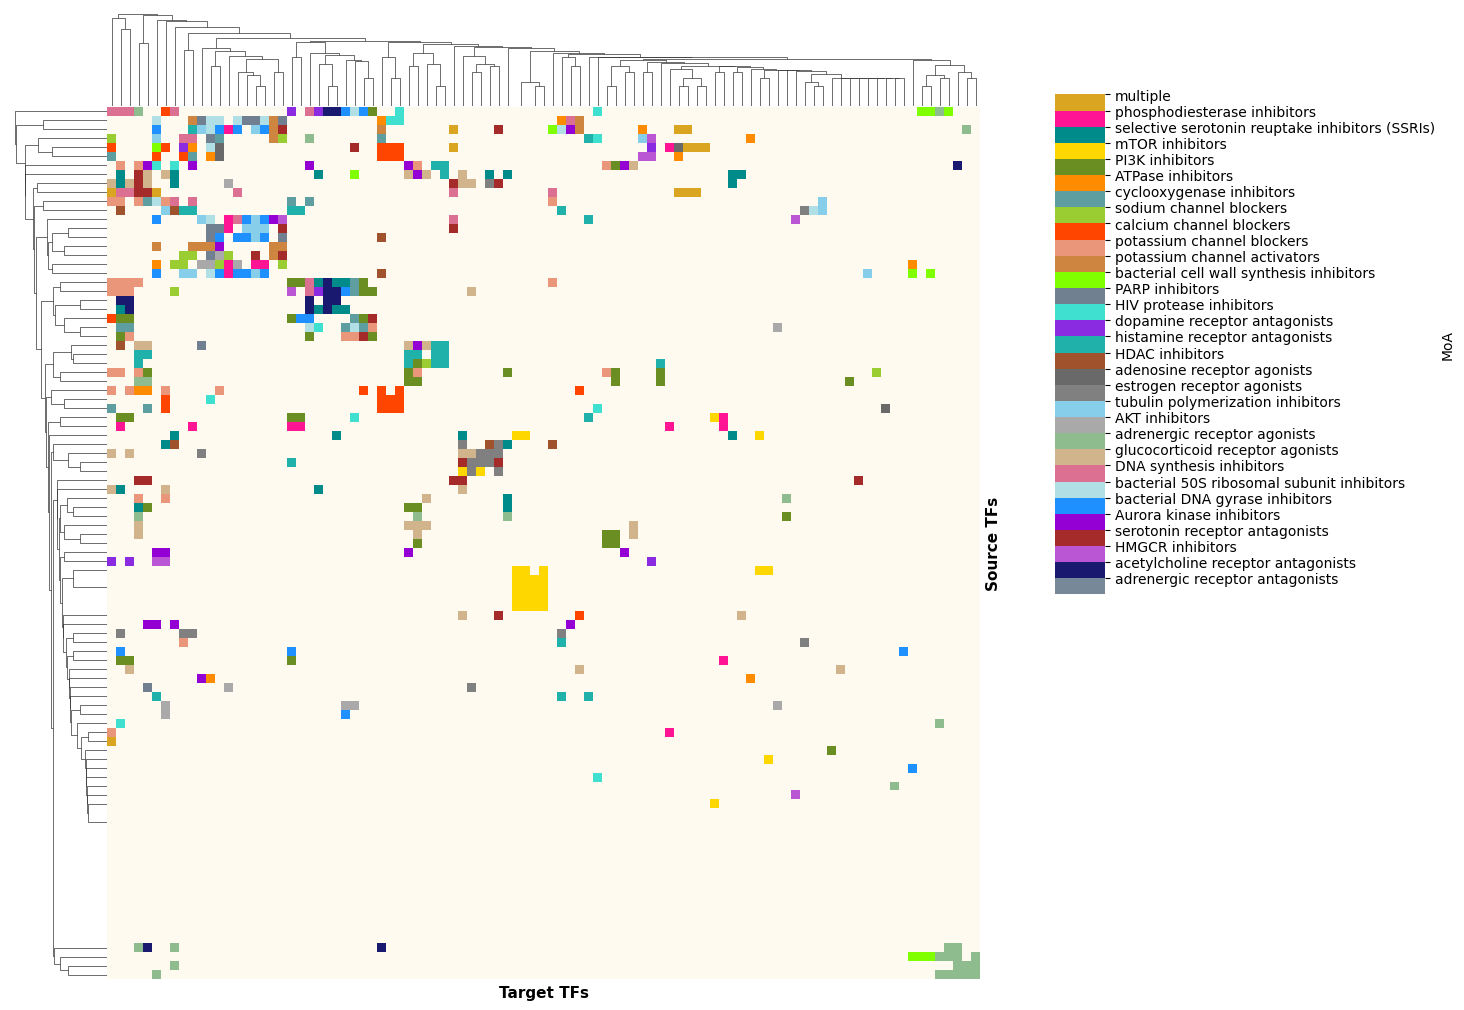

In [ ]:
def plot_moa_clustermap(combined_matrix, node_labels, colors=None,
                    figsize=(18, 16), save_path=None, cmap='viridis',
                    binary=False, maskzero=False, cbar_pos=None):

    # Create DataFrame for plotting (signed values for coloring)
    df = pd.DataFrame(combined_matrix, index=node_labels, columns=node_labels)

    

    fontsize = 5

    if binary:
        cluster_matrix = (combined_matrix != 0).astype(int)
    else:
        cluster_matrix = combined_matrix.copy()
    
    if maskzero:
        cmap.set_bad(color='floralwhite')

    # Compute linkage on cluster_matrix (NOT the colored matrix)
    row_linkage = linkage(pdist(cluster_matrix), method='average')
    col_linkage = linkage(pdist(cluster_matrix.T), method='average')

    # Coloring range still based on signed matrix
    vmin = 0
    vmax = len(colors)

    # Mask zeros visually if desired
    if binary:
        df = df.replace(0, np.nan)

    g = sns.clustermap(df,
                       cmap=cmap,
                       vmin=vmin,
                       vmax=vmax,
                       row_linkage=row_linkage,
                       col_linkage=col_linkage,
                       figsize=figsize,
                       cbar_kws={'label': 'MoA'},
                       dendrogram_ratio=0.1,
                       linewidths=0,
                       xticklabels=False,
                       yticklabels=False,
                       cbar_pos=(1.06,0.4,0.05,0.5)
                       )

    g.ax_heatmap.set_xlabel('Target TFs', fontsize=11, fontweight='bold')
    g.ax_heatmap.set_ylabel('Source TFs', fontsize=11, fontweight='bold')
    
    g.cax.set_yticks(list(colors.values()))
    g.cax.set_yticklabels(list(colors.keys()))

    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(),
             rotation=90, ha='center', fontsize=fontsize)
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(),
             rotation=0, fontsize=fontsize)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.savefig(save_path.replace(".png", ".svg"),
                    dpi=300, bbox_inches='tight')

    return g

output_prefix = "moa"
terms = list(set(x.split(":")[0] for x in networks.keys()))
moa_to_values = dict(zip(terms, list(range(1,len(terms) + 1))))
moa_to_values['multiple'] = len(terms) + 1

# Create adjacency matrices
all_nodes, adj_matrix= create_adjacency_matrices_moa(networks, moa_to_values=moa_to_values)
print(f"Found {len(all_nodes)} unique nodes")
 
# combined_matrix = np.where(combined_matrix != 0,1,0)
# Get node labels
node_labels = get_node_labels(networks, all_nodes)

filtered = [c for c in mcolors.CSS4_COLORS
            if 0.2126*mcolors.to_rgb(c)[0] +
               0.7152*mcolors.to_rgb(c)[1] +
               0.0722*mcolors.to_rgb(c)[2] < 0.85]

# Select 5 random colors
random.seed(40)
moa_colors = random.sample(filtered, len(moa_to_values))
moa_cmap = ListedColormap(moa_colors)

g = plot_moa_clustermap(
    adj_matrix,
    node_labels,
    save_path=f"./moa_atlas_figs/{output_prefix}_clustermap.png",
    colors=moa_to_values,
    figsize=(10,10),
    cmap=moa_cmap,
    binary=True,
    maskzero=True,
)

plt.show()

In [191]:
def plot_moa_clustermap(combined_matrix, node_labels, colors=None,
                    figsize=(18, 16), save_path=None, cmap='viridis',
                    binary=False, maskzero=False, cbar_pos=None):

    # Create DataFrame for plotting (signed values for coloring)
    df = pd.DataFrame(combined_matrix, index=node_labels, columns=node_labels)

    fontsize = 5

    if binary:
        cluster_matrix = (combined_matrix != 0).astype(int)
    else:
        cluster_matrix = combined_matrix.copy()
    
    if maskzero:
        cmap.set_bad(color='floralwhite')

    # Compute linkage on cluster_matrix (NOT the colored matrix)
    row_linkage = linkage(pdist(cluster_matrix), method='average')
    col_linkage = linkage(pdist(cluster_matrix.T), method='average')

    # Coloring range still based on signed matrix
    vmin = 0
    vmax = len(colors)

    # Mask zeros visually if desired
    if binary:
        df = df.replace(0, np.nan)

    g = sns.clustermap(df,
                       cmap=cmap,
                       vmin=vmin,
                       vmax=vmax,
                       row_linkage=row_linkage,
                       col_linkage=col_linkage,
                       figsize=figsize,
                       cbar_kws={'label': 'MoA'},
                       dendrogram_ratio=0.1,
                       linewidths=0,
                       xticklabels=False,
                       yticklabels=False,
                       cbar_pos=(1.06,0.4,0.05,0.5)
                       )

    g.ax_heatmap.set_xlabel('Target TFs', fontsize=11, fontweight='bold')
    g.ax_heatmap.set_ylabel('Source TFs', fontsize=11, fontweight='bold')
    
    g.cax.set_yticks(list(colors.values()))
    g.cax.set_yticklabels(list(colors.keys()))

    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(),
             rotation=90, ha='center', fontsize=fontsize)
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(),
             rotation=0, fontsize=fontsize)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.savefig(save_path.replace(".png", ".svg"),
                    dpi=300, bbox_inches='tight')

    return g


def plot_per_group_subplots(networks, all_nodes, adj_matrix, node_labels,
                             row_order, col_order,
                             figsize=(20, 16), save_path=None):
    """
    6x5 grid of subplots, one per group (30 groups, 2 subgroups each).
    row_order / col_order: reordered indices from the clustermap dendrograms.
    Each subplot shows edges from both subgroups in two distinct colors.
    """
    # Extract group names (part before ":") and sort for consistent ordering
    groups = sorted(set(k.split(":")[0] for k in networks.keys()))
    assert len(groups) == 30, f"Expected 30 groups, got {len(groups)}"

    node_index = {n: i for i, n in enumerate(all_nodes)}
    n = len(all_nodes)

    # Two fixed colors for subgroup A and B
    sub_colors = ['#e41a1c', '#377eb8']  # red, blue

    nrows, ncols = 6, 5
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for ax_idx, group in enumerate(groups):
        ax = axes[ax_idx]

        # Find the two subgroups for this group
        subgroup_keys = sorted([k for k in networks.keys() if k.split(":")[0] == group])

        # Build a colored matrix for this group: 0=no edge, 1=subgroup A, 2=subgroup B
        color_matrix = np.zeros((n, n))

        for sub_idx, key in enumerate(subgroup_keys):
            net = networks[key]
            for src, tgt in zip(net['source'], net['target']):
                if src in node_index and tgt in node_index:
                    i, j = node_index[src], node_index[tgt]
                    color_matrix[i, j] = sub_idx + 1  # 1 or 2

        # Reorder rows/cols according to clustermap ordering
        color_matrix = color_matrix[np.ix_(row_order, col_order)]

        # Build an RGBA image: background white, subgroup A red, subgroup B blue
        rgba = np.ones((*color_matrix.shape, 4))  # white background
        for sub_idx, hex_color in enumerate(sub_colors):
            rgb = mcolors.to_rgb(hex_color)
            mask = color_matrix == (sub_idx + 1)
            rgba[mask, :3] = rgb
            rgba[mask, 3] = 1.0

        ax.imshow(rgba, aspect='auto', interpolation='none')
        ax.set_title(group, fontsize=6, pad=2)
        ax.set_xticks([])
        ax.set_yticks([])

    # Hide unused axes
    for ax_idx in range(len(groups), nrows * ncols):
        axes[ax_idx].set_visible(False)

    # Legend
    from matplotlib.patches import Patch
    # Use generic labels since subgroup names vary per group
    legend_elements = [
        Patch(facecolor=sub_colors[0], label='Subgroup A'),
        Patch(facecolor=sub_colors[1], label='Subgroup B'),
    ]
    fig.legend(handles=legend_elements, loc='lower right',
               fontsize=8, frameon=True)

    plt.suptitle('Edges by Group', fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches='tight')

    return fig

KeyError: 'source'

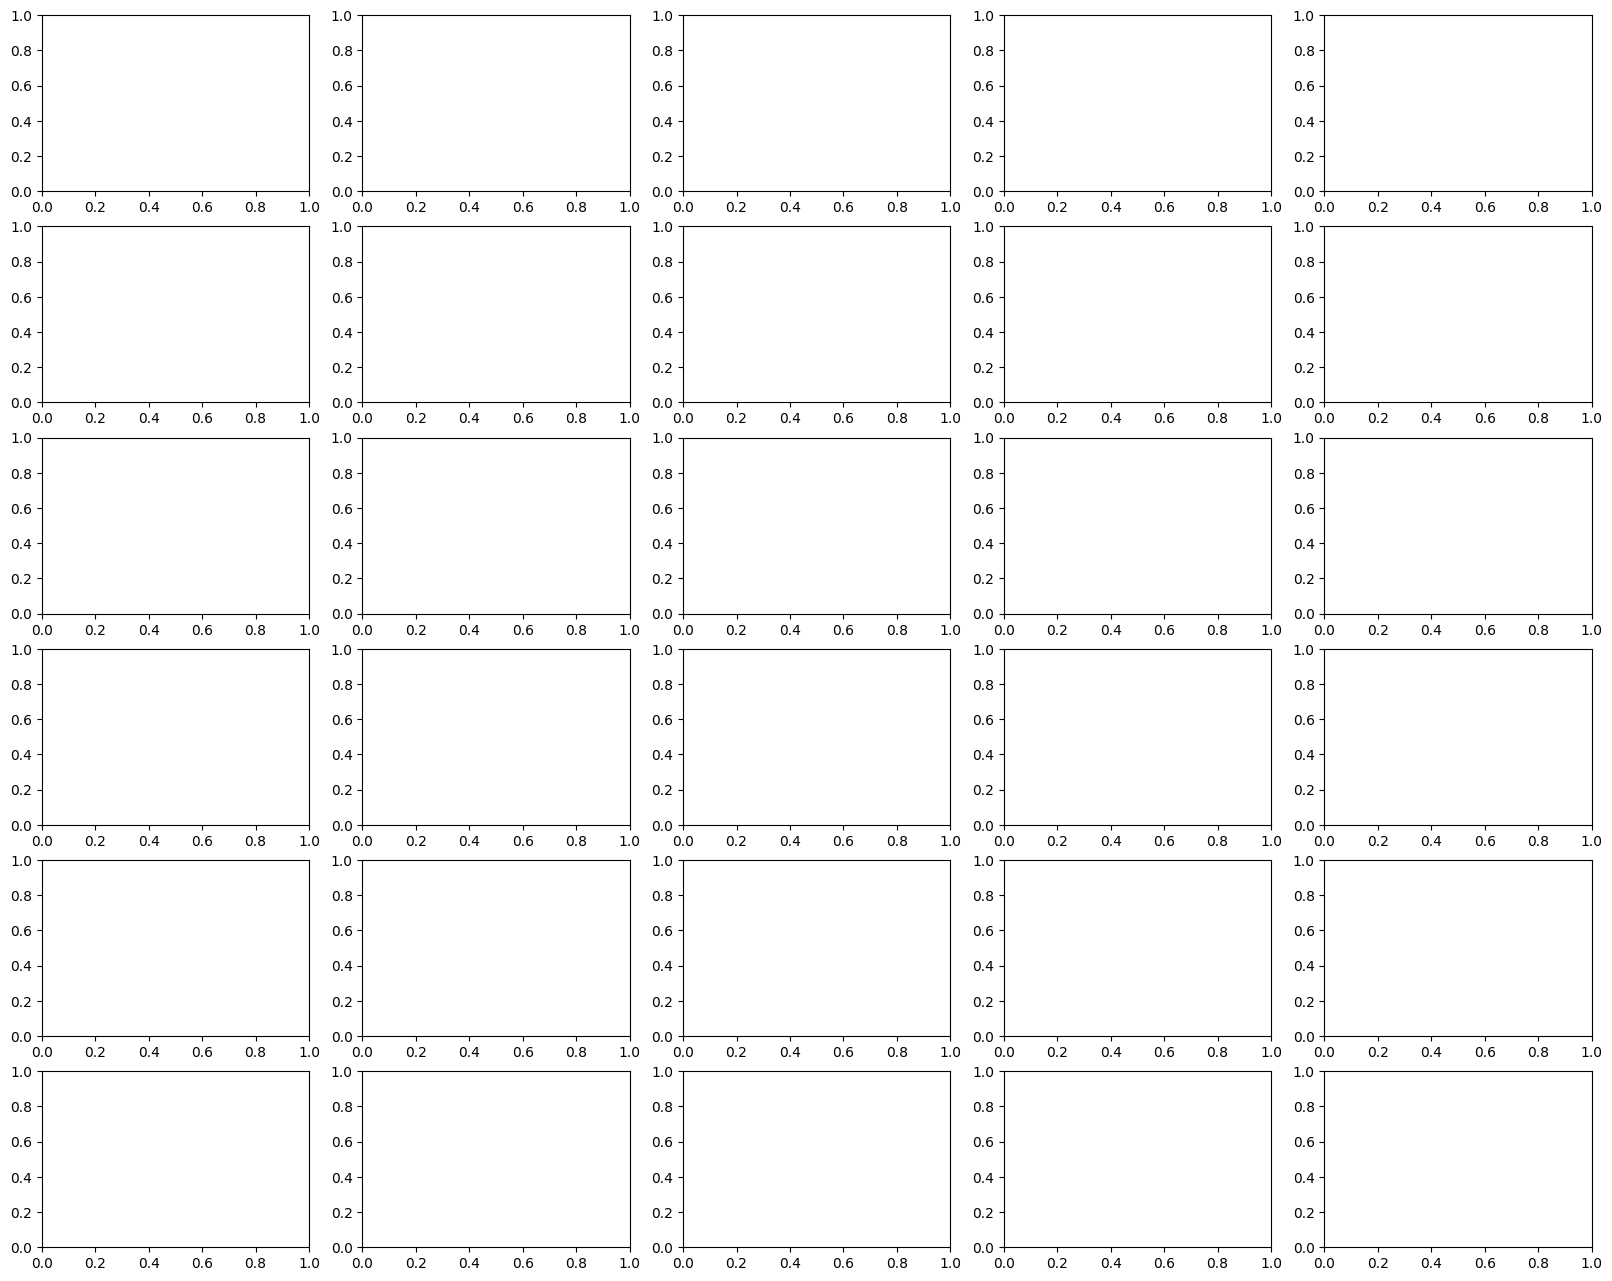

In [192]:
# ... your existing code to get g ...

# Extract the row/col ordering from the clustermap dendrograms
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind

fig_groups = plot_per_group_subplots(
    networks=networks,
    all_nodes=all_nodes,
    adj_matrix=adj_matrix,
    node_labels=node_labels,
    row_order=row_order,
    col_order=col_order,
    figsize=(20, 16),
    save_path=f"./moa_atlas_figs/{output_prefix}_per_group.png",
)
plt.show()

In [166]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from collections import defaultdict
import json

def create_interactive_adjacency_explorer(subnetworks_dict, output_html='subnetwork_explorer.html'):
    """
    Create an interactive 3D adjacency matrix explorer where you can:
    1. View individual subnetwork slices
    2. See which subnetworks contribute to each edge
    3. Filter and explore interactively
    
    Parameters:
    -----------
    subnetworks_dict : dict
        Dictionary of subnetworks
    output_html : str
        Output HTML filename
    """
    
    # Collect all unique nodes
    all_nodes = set()
    for data in subnetworks_dict.values():
        for node in data.get('nodes', []):
            all_nodes.add(node['data']['id'])
    
    all_nodes = sorted(list(all_nodes))
    n_nodes = len(all_nodes)
    node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
    
    # Get node labels
    id_to_label = {}
    for data in subnetworks_dict.values():
        for node in data.get('nodes', []):
            node_id = node['data']['id']
            id_to_label[node_id] = node['data'].get('label', str(node_id))
    
    node_labels = [id_to_label.get(node_id, str(node_id)) for node_id in all_nodes]
    
    # Create a 3D array: [subnetwork_index, source_node, target_node]
    subnetwork_names = list(subnetworks_dict.keys())
    n_subnetworks = len(subnetwork_names)
    
    # Store matrices for each subnetwork
    up_matrices_3d = np.zeros((n_subnetworks, n_nodes, n_nodes))
    down_matrices_3d = np.zeros((n_subnetworks, n_nodes, n_nodes))
    
    # Also track which subnetworks contribute to each edge
    edge_to_subnetworks = defaultdict(lambda: {'up': [], 'down': []})
    
    for sub_idx, (sub_name, sub_data) in enumerate(subnetworks_dict.items()):
        edges = sub_data.get('edges', [])
        
        for edge in edges:
            edge_data = edge['data']
            source = edge_data['source']
            target = edge_data['target']
            
            if source not in node_to_idx or target not in node_to_idx:
                continue
            
            i = node_to_idx[source]
            j = node_to_idx[target]
            
            relation = edge_data.get('relation', edge_data.get('label', ''))
            
            # Determine edge type
            is_up = False
            is_down = False
            
            if 'upregulate' in relation.lower() or 'activate' in relation.lower():
                is_up = True
            elif 'downregulate' in relation.lower() or 'inhibit' in relation.lower() or 'repress' in relation.lower():
                is_down = True
            else:
                line_color = edge_data.get('lineColor', '')
                if 'red' in line_color.lower() or '#c70a2d' in line_color:
                    is_down = True
                elif 'blue' in line_color.lower():
                    is_up = True
            
            if is_up:
                up_matrices_3d[sub_idx, i, j] = 1
                edge_to_subnetworks[(i, j)]['up'].append(sub_name)
            elif is_down:
                down_matrices_3d[sub_idx, i, j] = 1
                edge_to_subnetworks[(i, j)]['down'].append(sub_name)
    
    # Aggregate across subnetworks
    up_matrix_total = np.sum(up_matrices_3d, axis=0)
    down_matrix_total = np.sum(down_matrices_3d, axis=0)
    combined_matrix = up_matrix_total - down_matrix_total
    
    # Create the interactive visualization
    fig = create_interactive_heatmap_with_slider(
        up_matrices_3d, down_matrices_3d, 
        up_matrix_total, down_matrix_total,
        node_labels, subnetwork_names,
        edge_to_subnetworks
    )
    
    # Save to HTML
    output_path = f'./moa_atlas_figs/{output_html}'
    fig.write_html(output_path)
    print(f"Saved interactive visualization to {output_path}")
    
    return fig, edge_to_subnetworks


def create_interactive_heatmap_with_slider(up_3d, down_3d, up_total, down_total, 
                                           node_labels, subnetwork_names, edge_to_subnetworks):
    """
    Create an interactive heatmap with a slider to navigate through subnetworks.
    """
    
    n_subnetworks, n_nodes, _ = up_3d.shape
    combined_3d = up_3d - down_3d
    combined_total = up_total - down_total
    
    # Create figure
    fig = go.Figure()
    
    # Determine global color scale
    max_val = max(np.max(np.abs(combined_total)), 1)
    
    # Add the aggregated view as the first frame
    hovertext_total = create_hovertext(combined_total, up_total, down_total, 
                                       node_labels, edge_to_subnetworks)
    
    fig.add_trace(go.Heatmap(
        z=combined_total,
        x=node_labels,
        y=node_labels,
        colorscale=create_custom_colorscale(),
        zmid=0,
        zmin=-max_val,
        zmax=max_val,
        text=hovertext_total,
        hovertemplate='<b>%{y} → %{x}</b><br>%{text}<extra></extra>',
        colorbar=dict(
            title="Edge<br>Frequency",
            ticktext=['Down', '0', 'Up'],
            tickvals=[-max_val, 0, max_val],
            len=0.7
        ),
        visible=True
    ))
    
    # Add individual subnetwork slices
    for sub_idx in range(n_subnetworks):
        combined_slice = combined_3d[sub_idx]
        up_slice = up_3d[sub_idx]
        down_slice = down_3d[sub_idx]
        
        hovertext_slice = create_hovertext_slice(combined_slice, up_slice, down_slice, 
                                                 node_labels, subnetwork_names[sub_idx])
        
        fig.add_trace(go.Heatmap(
            z=combined_slice,
            x=node_labels,
            y=node_labels,
            colorscale=create_custom_colorscale(),
            zmid=0,
            zmin=-1.5,
            zmax=1.5,
            text=hovertext_slice,
            hovertemplate='<b>%{y} → %{x}</b><br>%{text}<extra></extra>',
            colorbar=dict(
                title="Edge<br>Type",
                ticktext=['Down', 'None', 'Up'],
                tickvals=[-1, 0, 1],
                len=0.7
            ),
            visible=False
        ))
    
    # Create slider steps
    steps = []
    
    # First step: Aggregated view
    step = dict(
        method="update",
        args=[{"visible": [True] + [False] * n_subnetworks},
              {"title": f"<b>All Subnetworks (Aggregated)</b><br><sub>Total: {n_subnetworks} subnetworks | Nodes: {n_nodes}</sub>"}],
        label="ALL"
    )
    steps.append(step)
    
    # Individual subnetwork steps
    for sub_idx in range(n_subnetworks):
        visible = [False] * (n_subnetworks + 1)
        visible[sub_idx + 1] = True
        
        # Count edges in this subnetwork
        n_up_edges = np.sum(up_3d[sub_idx] > 0)
        n_down_edges = np.sum(down_3d[sub_idx] > 0)
        
        step = dict(
            method="update",
            args=[{"visible": visible},
                  {"title": f"<b>{subnetwork_names[sub_idx]}</b><br><sub>↑{n_up_edges} up | ↓{n_down_edges} down</sub>"}],
            label=f"{sub_idx+1}"
        )
        steps.append(step)
    
    # Add slider
    sliders = [dict(
        active=0,
        yanchor="top",
        y=-0.15,
        xanchor="left",
        currentvalue=dict(
            prefix="Subnetwork: ",
            visible=True,
            xanchor="left"
        ),
        pad=dict(b=10, t=50),
        len=0.9,
        x=0.05,
        steps=steps
    )]
    
    fig.update_layout(
        sliders=sliders,
        title=f"<b>All Subnetworks (Aggregated)</b><br><sub>Total: {n_subnetworks} subnetworks | Nodes: {n_nodes}</sub>",
        xaxis=dict(
            title="Target Node",
            tickangle=-45,
            side='bottom'
        ),
        yaxis=dict(
            title="Source Node"
        ),
        width=1200,
        height=1000,
        font=dict(size=10)
    )
    
    return fig


def create_hovertext(combined, up, down, node_labels, edge_to_subnetworks):
    """Create detailed hover text for aggregated view."""
    n = len(node_labels)
    hovertext = []
    
    for i in range(n):
        row = []
        for j in range(n):
            up_count = int(up[i, j])
            down_count = int(down[i, j])
            
            text_parts = []
            
            if up_count > 0:
                text_parts.append(f"↑ Up: {up_count}")
                # List subnetworks
                if (i, j) in edge_to_subnetworks and edge_to_subnetworks[(i, j)]['up']:
                    subs = edge_to_subnetworks[(i, j)]['up']
                    if len(subs) <= 3:
                        text_parts.append(f"  Networks: {', '.join(subs[:3])}")
                    else:
                        text_parts.append(f"  Networks: {', '.join(subs[:2])} + {len(subs)-2} more")
            
            if down_count > 0:
                text_parts.append(f"↓ Down: {down_count}")
                if (i, j) in edge_to_subnetworks and edge_to_subnetworks[(i, j)]['down']:
                    subs = edge_to_subnetworks[(i, j)]['down']
                    if len(subs) <= 3:
                        text_parts.append(f"  Networks: {', '.join(subs[:3])}")
                    else:
                        text_parts.append(f"  Networks: {', '.join(subs[:2])} + {len(subs)-2} more")
            
            if not text_parts:
                text_parts.append("No edge")
            
            row.append('<br>'.join(text_parts))
        
        hovertext.append(row)
    
    return hovertext


def create_hovertext_slice(combined, up, down, node_labels, subnetwork_name):
    """Create hover text for individual subnetwork slice."""
    n = len(node_labels)
    hovertext = []
    
    for i in range(n):
        row = []
        for j in range(n):
            if up[i, j] > 0:
                text = f"↑ Upregulates<br>Network: {subnetwork_name}"
            elif down[i, j] > 0:
                text = f"↓ Downregulates<br>Network: {subnetwork_name}"
            else:
                text = "No edge"
            
            row.append(text)
        
        hovertext.append(row)
    
    return hovertext


def create_custom_colorscale():
    """Create blue-white-red diverging colorscale."""
    return [
        [0.0, '#08306b'],   # Dark blue
        [0.25, '#4292c6'],  # Medium blue
        [0.45, '#c6dbef'],  # Light blue
        [0.5, '#ffffff'],   # White
        [0.55, '#fcbba1'],  # Light red
        [0.75, '#fb6a4a'],  # Medium red
        [1.0, '#a50f15']    # Dark red
    ]


def create_3d_surface_plot(subnetworks_dict, output_html='subnetwork_3d_surface.html'):
    """
    Create a true 3D surface plot where Z-axis represents different subnetworks.
    This gives a 3D "stack" view of all adjacency matrices.
    """
    
    # Collect all unique nodes
    all_nodes = set()
    for data in subnetworks_dict.values():
        for node in data.get('nodes', []):
            all_nodes.add(node['data']['id'])
    
    all_nodes = sorted(list(all_nodes))
    n_nodes = len(all_nodes)
    node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
    
    # Get node labels
    id_to_label = {}
    for data in subnetworks_dict.values():
        for node in data.get('nodes', []):
            node_id = node['data']['id']
            id_to_label[node_id] = node['data'].get('label', str(node_id))
    
    node_labels = [id_to_label.get(node_id, str(node_id)) for node_id in all_nodes]
    
    # Create matrices for each subnetwork
    subnetwork_names = list(subnetworks_dict.keys())
    n_subnetworks = len(subnetwork_names)
    
    combined_3d = np.zeros((n_subnetworks, n_nodes, n_nodes))
    
    for sub_idx, (sub_name, sub_data) in enumerate(subnetworks_dict.items()):
        edges = sub_data.get('edges', [])
        
        for edge in edges:
            edge_data = edge['data']
            source = edge_data['source']
            target = edge_data['target']
            
            if source not in node_to_idx or target not in node_to_idx:
                continue
            
            i = node_to_idx[source]
            j = node_to_idx[target]
            
            relation = edge_data.get('relation', edge_data.get('label', ''))
            
            # Determine edge type
            if 'upregulate' in relation.lower() or 'activate' in relation.lower():
                combined_3d[sub_idx, i, j] = 1  # Up
            elif 'downregulate' in relation.lower() or 'inhibit' in relation.lower() or 'repress' in relation.lower():
                combined_3d[sub_idx, i, j] = -1  # Down
            else:
                line_color = edge_data.get('lineColor', '')
                if 'red' in line_color.lower() or '#c70a2d' in line_color:
                    combined_3d[sub_idx, i, j] = -1
                elif 'blue' in line_color.lower():
                    combined_3d[sub_idx, i, j] = 1
    
    # Create 3D scatter plot of edges
    fig = go.Figure()
    
    # Add points for each edge across all subnetworks
    for sub_idx in range(n_subnetworks):
        for i in range(n_nodes):
            for j in range(n_nodes):
                if combined_3d[sub_idx, i, j] != 0:
                    edge_type = 'Up' if combined_3d[sub_idx, i, j] > 0 else 'Down'
                    color = '#de2d26' if combined_3d[sub_idx, i, j] > 0 else '#2171b5'
                    
                    fig.add_trace(go.Scatter3d(
                        x=[i],
                        y=[j],
                        z=[sub_idx],
                        mode='markers',
                        marker=dict(
                            size=5,
                            color=color,
                            opacity=0.7
                        ),
                        text=f"{node_labels[i]} → {node_labels[j]}<br>{edge_type}<br>{subnetwork_names[sub_idx]}",
                        hoverinfo='text',
                        showlegend=False
                    ))
    
    # Update layout
    fig.update_layout(
        title=f"<b>3D View: Edges Across {n_subnetworks} Subnetworks</b>",
        scene=dict(
            xaxis=dict(title="Source Node Index", showticklabels=False),
            yaxis=dict(title="Target Node Index", showticklabels=False),
            zaxis=dict(title="Subnetwork Index"),
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.3)
            )
        ),
        width=1200,
        height=900
    )
    
    # Save
    output_path = f'./moa_atlas_figs/{output_html}'
    fig.write_html(output_path)
    print(f"Saved 3D surface plot to {output_path}")
    fig.show()
    return fig


def create_subnetwork_dropdown_explorer(subnetworks_dict, output_html='subnetwork_dropdown.html'):
    """
    Create an interactive explorer with dropdown menu to select subnetworks.
    Includes checkboxes to show/hide individual subnetworks and overlay them.
    """
    
    # Prepare data
    all_nodes = set()
    for data in subnetworks_dict.values():
        for node in data.get('nodes', []):
            all_nodes.add(node['data']['id'])
    
    all_nodes = sorted(list(all_nodes))
    n_nodes = len(all_nodes)
    node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
    
    id_to_label = {}
    for data in subnetworks_dict.values():
        for node in data.get('nodes', []):
            node_id = node['data']['id']
            id_to_label[node_id] = node['data'].get('label', str(node_id))
    
    node_labels = [id_to_label.get(node_id, str(node_id)) for node_id in all_nodes]
    
    subnetwork_names = list(subnetworks_dict.keys())
    n_subnetworks = len(subnetwork_names)
    
    # Create matrices
    matrices = {}
    for sub_idx, (sub_name, sub_data) in enumerate(subnetworks_dict.items()):
        matrix = np.zeros((n_nodes, n_nodes))
        
        edges = sub_data.get('edges', [])
        for edge in edges:
            edge_data = edge['data']
            source = edge_data['source']
            target = edge_data['target']
            
            if source not in node_to_idx or target not in node_to_idx:
                continue
            
            i = node_to_idx[source]
            j = node_to_idx[target]
            
            relation = edge_data.get('relation', edge_data.get('label', ''))
            
            if 'upregulate' in relation.lower() or 'activate' in relation.lower():
                matrix[i, j] = 1
            elif 'downregulate' in relation.lower() or 'inhibit' in relation.lower() or 'repress' in relation.lower():
                matrix[i, j] = -1
            else:
                line_color = edge_data.get('lineColor', '')
                if 'red' in line_color.lower() or '#c70a2d' in line_color:
                    matrix[i, j] = -1
                elif 'blue' in line_color.lower():
                    matrix[i, j] = 1
        
        matrices[sub_name] = matrix
    
    # Create aggregated matrix
    aggregated = sum(matrices.values())
    
    # Create figure with dropdown
    fig = go.Figure()
    
    # Add aggregated view
    fig.add_trace(go.Heatmap(
        z=aggregated,
        x=node_labels,
        y=node_labels,
        colorscale=create_custom_colorscale(),
        zmid=0,
        hovertemplate='<b>%{y} → %{x}</b><br>Value: %{z}<extra></extra>',
        colorbar=dict(title="Frequency"),
        name="All Networks"
    ))
    
    # Add individual subnetwork traces
    for sub_name, matrix in matrices.items():
        n_edges = np.sum(np.abs(matrix) > 0)
        fig.add_trace(go.Heatmap(
            z=matrix,
            x=node_labels,
            y=node_labels,
            colorscale=create_custom_colorscale(),
            zmid=0,
            zmin=-1.5,
            zmax=1.5,
            hovertemplate='<b>%{y} → %{x}</b><br>Value: %{z}<extra></extra>',
            colorbar=dict(title="Edge Type"),
            visible=False,
            name=f"{sub_name} ({n_edges} edges)"
        ))
    
    # Create dropdown buttons
    buttons = []
    
    # Aggregated view button
    buttons.append(dict(
        label="All Networks (Aggregated)",
        method="update",
        args=[{"visible": [True] + [False] * n_subnetworks},
              {"title": f"All Subnetworks - Aggregated View"}]
    ))
    
    # Individual subnetwork buttons
    for idx, sub_name in enumerate(subnetwork_names):
        visible = [False] * (n_subnetworks + 1)
        visible[idx + 1] = True
        
        n_edges = np.sum(np.abs(matrices[sub_name]) > 0)
        
        buttons.append(dict(
            label=f"{sub_name} ({n_edges} edges)",
            method="update",
            args=[{"visible": visible},
                  {"title": f"Subnetwork: {sub_name}"}]
        ))
    
    # Update layout
    fig.update_layout(
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0.01,
                xanchor="left",
                y=1.15,
                yanchor="top"
            )
        ],
        title="All Subnetworks - Aggregated View",
        xaxis=dict(title="Target Node", tickangle=-45),
        yaxis=dict(title="Source Node"),
        width=1200,
        height=1000
    )
    
    # Save
    output_path = f'./moa_atlas_figs/{output_html}'
    fig.write_html(output_path)
    print(f"Saved dropdown explorer to {output_path}")
    fig.show()
    return fig


def create_all_interactive_visualizations(subnetworks_dict, output_prefix='interactive'):
    """
    Create all three types of interactive visualizations.
    
    Parameters:
    -----------
    subnetworks_dict : dict
        Dictionary of subnetworks
    output_prefix : str
        Prefix for output files
    
    Returns:
    --------
    dict : Dictionary with all created figures
    """
    
    print(f"Creating interactive visualizations for {len(subnetworks_dict)} subnetworks...")
    
    results = {}
    
    # 1. Slider-based explorer
    print("\n1. Creating slider-based explorer...")
    fig1, edge_info = create_interactive_adjacency_explorer(
        subnetworks_dict,
        output_html=f'{output_prefix}_slider_explorer.html'
    )
    results['slider_explorer'] = fig1
    results['edge_to_subnetworks'] = edge_info
    
    # 2. 3D surface plot
    print("\n2. Creating 3D surface plot...")
    fig2 = create_3d_surface_plot(
        subnetworks_dict,
        output_html=f'{output_prefix}_3d_surface.html'
    )
    results['3d_surface'] = fig2
    
    # 3. Dropdown explorer
    print("\n3. Creating dropdown explorer...")
    fig3 = create_subnetwork_dropdown_explorer(
        subnetworks_dict,
        output_html=f'{output_prefix}_dropdown.html'
    )
    results['dropdown_explorer'] = fig3
    
    print("\n✓ All interactive visualizations created!")
    print(f"\nFiles saved in ./moa_atlas_figs/:")
    print(f"  - {output_prefix}_slider_explorer.html (navigate with slider)")
    print(f"  - {output_prefix}_3d_surface.html (3D scatter view)")
    print(f"  - {output_prefix}_dropdown.html (dropdown menu)")
    
    return results

# Histogram of how many times a node appears in a network


(array([37., 21.,  6.,  5.,  5.,  2.,  4.,  3.,  0.,  1.,  1.,  0.,  1.,
         5.,  1.,  2.,  0.,  0.,  1.,  1.,  1.,  0.,  1.,  2.,  1.,  0.,
         1.,  0.,  0.,  2.]),
 array([ 1.        ,  1.96666667,  2.93333333,  3.9       ,  4.86666667,
         5.83333333,  6.8       ,  7.76666667,  8.73333333,  9.7       ,
        10.66666667, 11.63333333, 12.6       , 13.56666667, 14.53333333,
        15.5       , 16.46666667, 17.43333333, 18.4       , 19.36666667,
        20.33333333, 21.3       , 22.26666667, 23.23333333, 24.2       ,
        25.16666667, 26.13333333, 27.1       , 28.06666667, 29.03333333,
        30.        ]),
 <BarContainer object of 30 artists>)

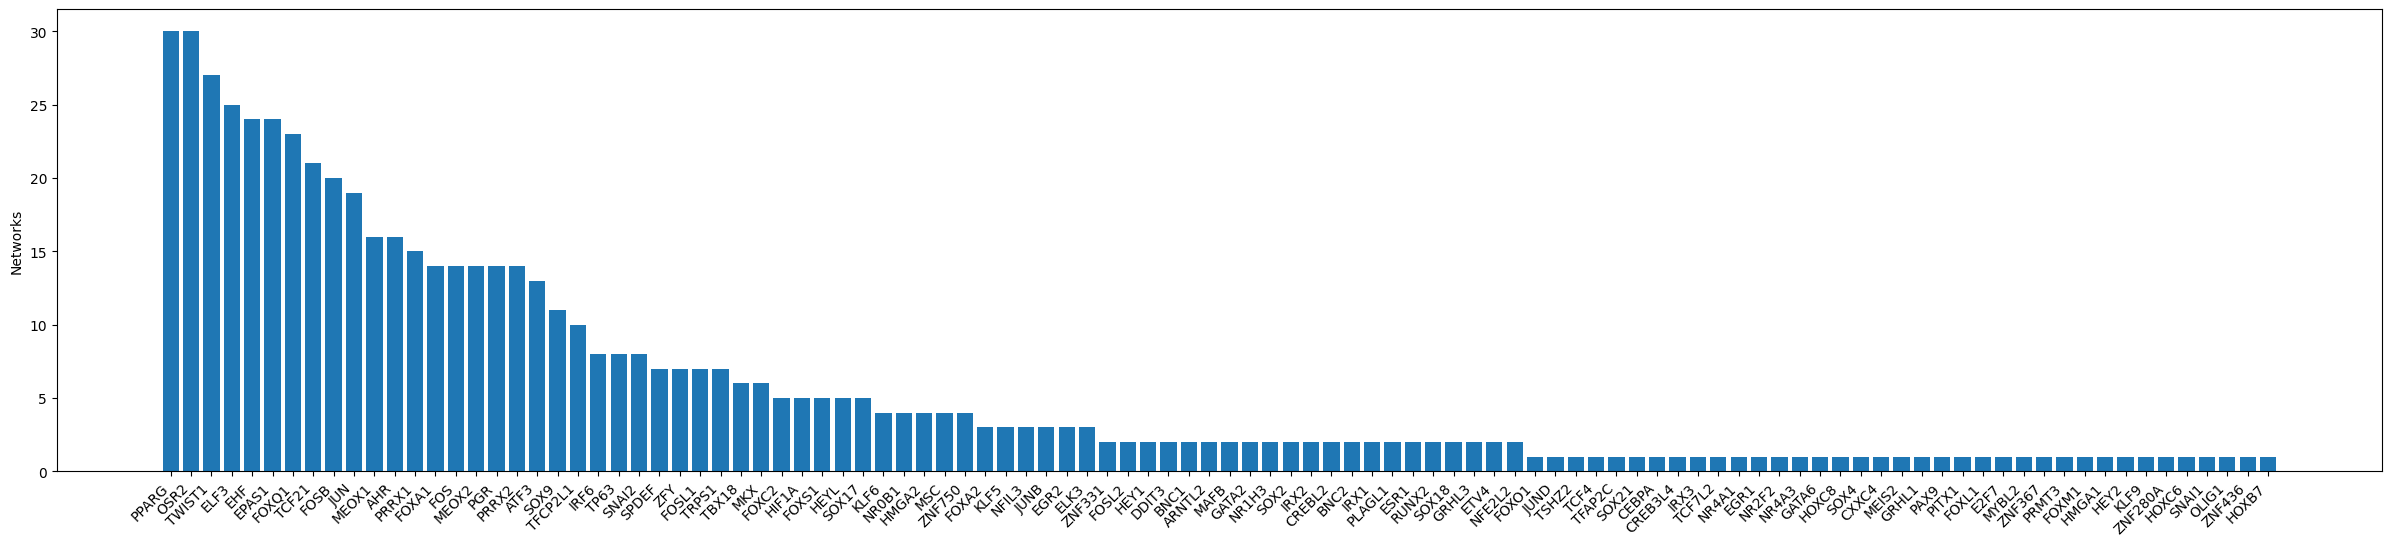

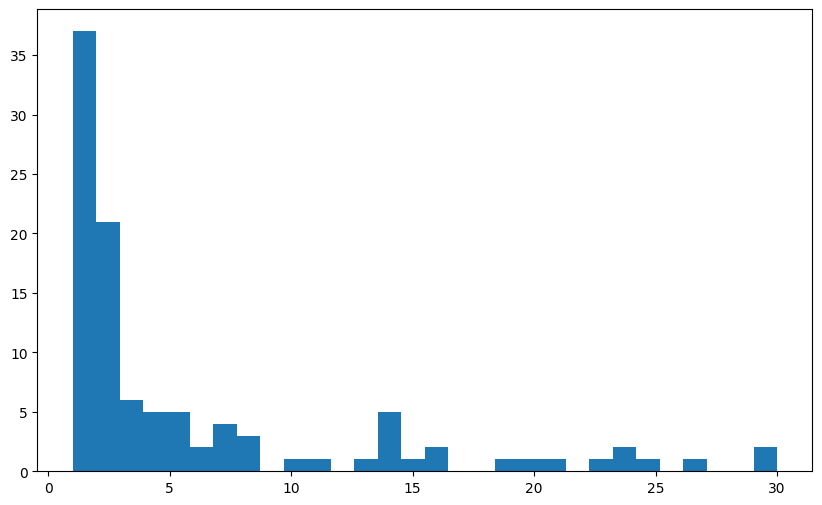

In [83]:
from collections import Counter
nodes = []
up_nodes = []
dn_nodes = []
for term, network_info in networks.items():
    net_nodes = [x['data']['label'] for x in network_info['nodes']]
    up_net_nodes = []
    dn_net_nodes = []
    if "up" in term:
        up_net_nodes = [x['data']['label'] for x in network_info['nodes']]
    elif "down" in term:
        dn_net_nodes = [x['data']['label'] for x in network_info['nodes']]
    nodes.extend(net_nodes)
    up_nodes.extend(up_net_nodes)
    dn_nodes.extend(dn_net_nodes)
node_counts = Counter(nodes)
node_counts_sorted = node_counts.most_common()
x = [x for x,y in node_counts_sorted]
y = [y for x,y in node_counts_sorted]

plt.figure(figsize=(30,6))
g = plt.bar(x, y)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Networks")
plt.figure(figsize=(10,6))
plt.hist(node_counts.values(), bins=30)

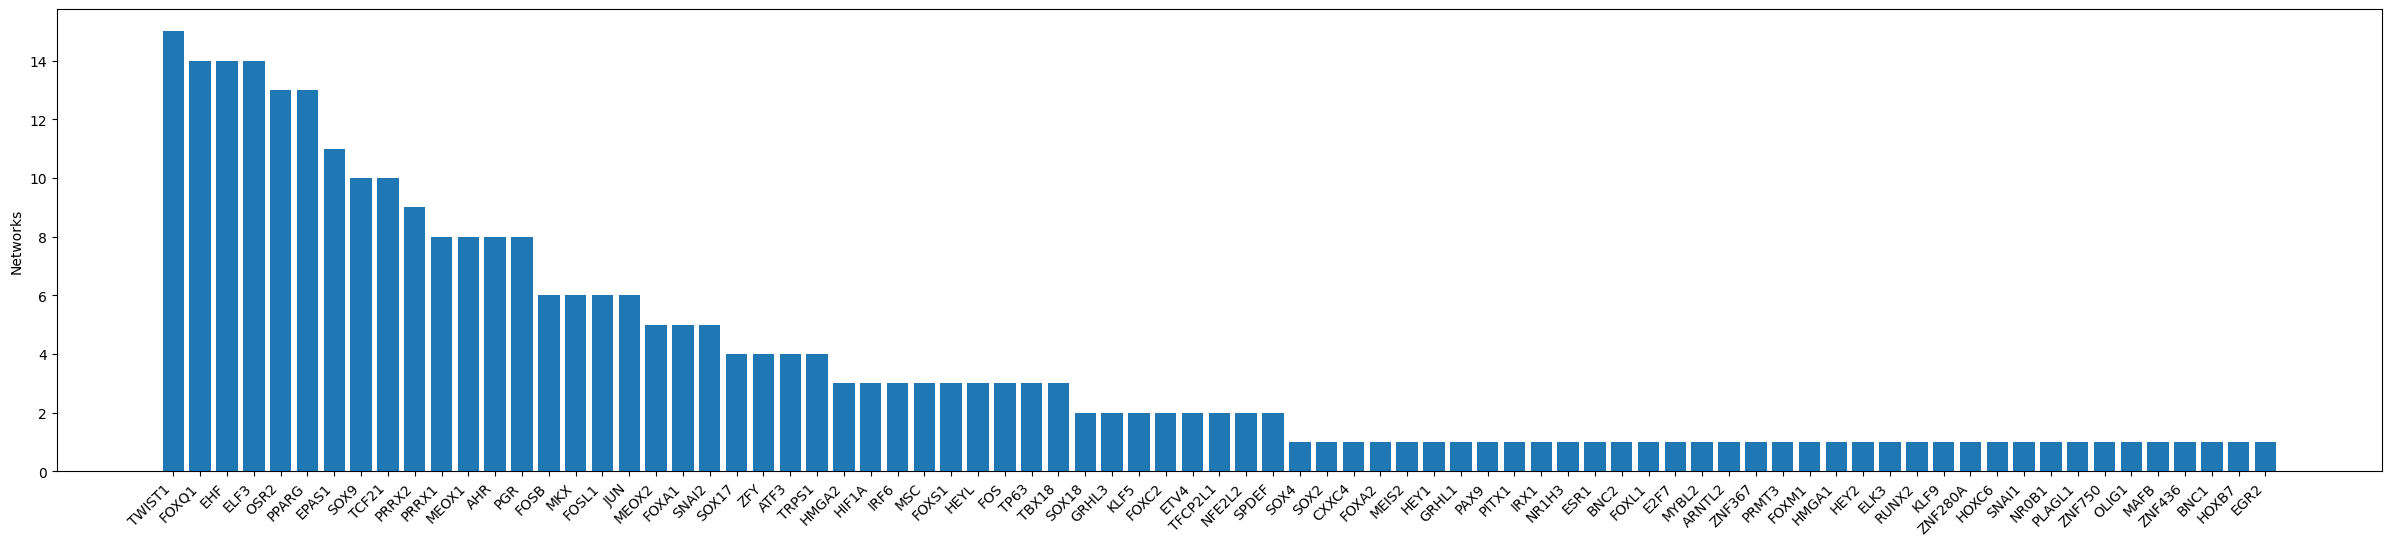

In [84]:
dn_node_counts = Counter(dn_nodes)
dn_node_counts_sorted = dn_node_counts.most_common()
x = [x for x,y in dn_node_counts_sorted]
y = [y for x,y in dn_node_counts_sorted]

plt.figure(figsize=(30,6))
plt.xticks(rotation=45, ha='right')
plt.ylabel("Networks")
g = plt.bar(x, y)

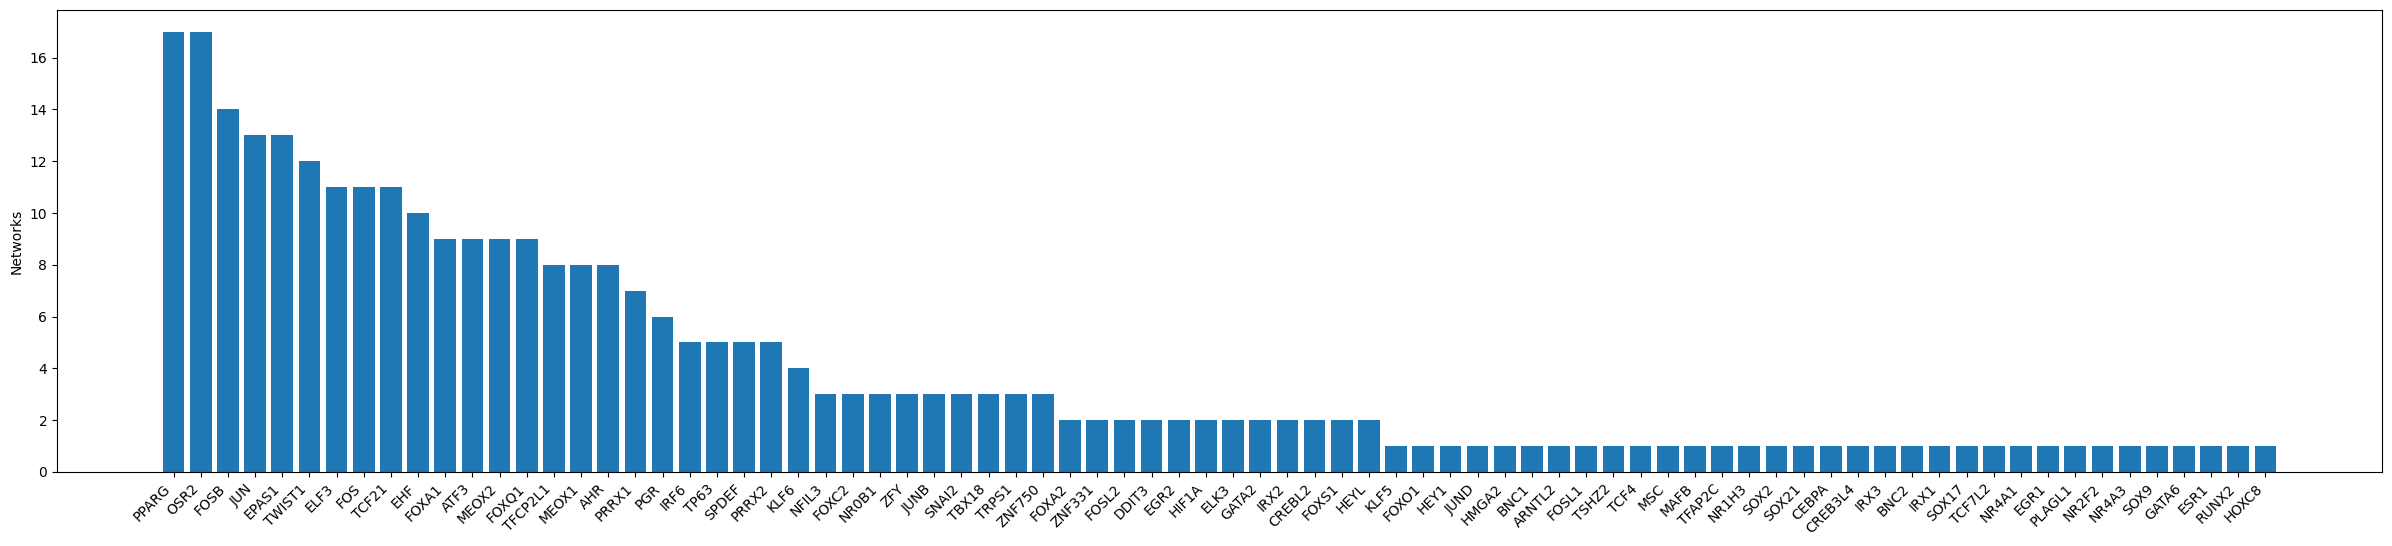

In [ ]:
up_node_counts = Counter(up_nodes)
up_node_counts_sorted = up_node_counts.most_common()
x = [x for x,y in up_node_counts_sorted]
y = [y for x,y in up_node_counts_sorted]

plt.figure(figsize=(30,6))
plt.xticks(rotation=45, ha='right')
plt.ylabel("Networks")
g = plt.bar(x, y)